<a href="https://colab.research.google.com/github/halimAhtasham/DeepLearning/blob/main/06_Cross_Validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Phase 6: Cross Validation**

Objective

Evaluate the stability and generalization performance of the baseline
machine learning models using Stratified K-Fold Cross-Validation.

Models:
1. Logistic Regression
2. K-Nearest Neighbors
3. Decision Tree
4. Random Forest

Evaluation metrics:
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import drive

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

### **Drive Mount**

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
PROJECT_PATH = "/content/drive/MyDrive/Machine Learning/Projects/Heart Disease Prediction"

DATASET_PATH = PROJECT_PATH + "/Dataset"
RESULT_PATH = PROJECT_PATH + "/Results"

# Load and Clean Dataset

In [ ]:
df = pd.read_csv(DATASET_PATH + "/heart.csv")

df_clean = df.drop_duplicates().copy()

print("Original:", df.shape)
print("Cleaned:", df_clean.shape)

Original: (1025, 14)
Cleaned: (302, 14)


# **Separate X and y**

In [ ]:
X = df_clean.drop("target", axis=1)
y = df_clean["target"]

In [ ]:
print("X:", X.shape)
print("y:", y.shape)

X: (302, 13)
y: (302,)


# **Train / Test Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
print("X_train", X_train.shape)
print("y_train", y_train.shape)
print("X_test", X_test.shape)
print("y_test", y_test.shape)

X_train (241, 13)
y_train (241,)
X_test (61, 13)
y_test (61,)


#Stratified 5-Fold Cross-Validation

The training dataset is divided into five folds.

For each iteration:
- Four folds are used for training.
- One fold is used for validation.
- The process is repeated five times.
- Every sample is used for validation exactly once.

Stratification maintains approximately the same class distribution
across the folds.

In [ ]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

## *Pipeline*

In [ ]:
logistic_pipeline = Pipeline([
    ("Scaler", StandardScaler()),
    ("model", LogisticRegression(
        random_state=42,
        max_iter=1000
    ))
])

# **Metrics and Logistic Cross Validation**

In [ ]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

In [ ]:
logistic_cv = cross_validate(
    logistic_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

In [ ]:
print(logistic_cv)

{'fit_time': array([0.09738016, 0.04505539, 0.03949928, 0.03892851, 0.04448581]), 'score_time': array([0.07963896, 0.04363084, 0.04030848, 0.0426631 , 0.0438323 ]), 'test_accuracy': array([0.89795918, 0.79166667, 0.83333333, 0.95833333, 0.70833333]), 'test_precision': array([0.89285714, 0.80769231, 0.84615385, 0.92857143, 0.66666667]), 'test_recall': array([0.92592593, 0.80769231, 0.84615385, 1.        , 0.92307692]), 'test_f1': array([0.90909091, 0.80769231, 0.84615385, 0.96296296, 0.77419355]), 'test_roc_auc': array([0.96632997, 0.88111888, 0.88986014, 0.94755245, 0.88286713])}


## *Mean and Standard Deviation for Logistic CV*

In [ ]:
print(
    "Mean Accuracy:",
    logistic_cv["test_accuracy"].mean()
)

print(
    "Std Accuracy:",
    logistic_cv["test_accuracy"].std()
)

Mean Accuracy: 0.8379251700680272
Std Accuracy: 0.08608970533148125


In [ ]:
for metric in scoring.keys():
    scores = logistic_cv[f"test_{metric}"]

    print(
        f"{metric}: "
        f"{scores.mean():.4f} ± {scores.std():.4f}"
    )

accuracy: 0.8379 ± 0.0861
precision: 0.8284 ± 0.0907
recall: 0.9006 ± 0.0673
f1: 0.8600 ± 0.0683
roc_auc: 0.9135 ± 0.0360


# **Cross Validation for 4 models(Logistic Regressio, KNN, Random Forest, Decision Tree)**

In [ ]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            random_state=42,
            max_iter=1000
        ))
    ]),

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(
            n_neighbors=5
        ))
    ]),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )
}

In [ ]:
cv_results = []

for name, model in models.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False
    )

    cv_results.append({
        "Model": name,

        "Accuracy Mean": scores["test_accuracy"].mean(),
        "Accuracy Std": scores["test_accuracy"].std(),

        "Precision Mean": scores["test_precision"].mean(),
        "Precision Std": scores["test_precision"].std(),

        "Recall Mean": scores["test_recall"].mean(),
        "Recall Std": scores["test_recall"].std(),

        "F1 Mean": scores["test_f1"].mean(),
        "F1 Std": scores["test_f1"].std(),

        "ROC-AUC Mean": scores["test_roc_auc"].mean(),
        "ROC-AUC Std": scores["test_roc_auc"].std()
    })

In [ ]:
cv_results_df = pd.DataFrame(cv_results)

cv_results_df

,Model,Accuracy Mean,Accuracy Std,Precision Mean,Precision Std,Recall Mean,Recall Std,F1 Mean,F1 Std,ROC-AUC Mean,ROC-AUC Std
0,Logistic Regression,0.837925,0.086090,0.828388,0.090654,0.900570,0.067265,0.860019,0.068267,0.913546,0.036045
1,KNN,0.829762,0.048555,0.838877,0.068683,0.862678,0.051885,0.847423,0.036570,0.900602,0.026355
2,Decision Tree,0.780102,0.028045,0.781481,0.038554,0.832194,0.057061,0.804038,0.027376,0.775188,0.029139
3,Random Forest,0.850425,0.038704,0.844809,0.050642,0.892877,0.045257,0.866644,0.033326,0.906935,0.043959


In [ ]:
for name, model in models.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False
    )

    print("=" * 60)
    print(name)
    print("=" * 60)

    print("Accuracy:", np.round(scores["test_accuracy"], 4))
    print("F1:", np.round(scores["test_f1"], 4))
    print("ROC-AUC:", np.round(scores["test_roc_auc"], 4))

Logistic Regression
Accuracy: [0.898  0.7917 0.8333 0.9583 0.7083]
F1: [0.9091 0.8077 0.8462 0.963  0.7742]
ROC-AUC: [0.9663 0.8811 0.8899 0.9476 0.8829]
KNN
Accuracy: [0.8571 0.8333 0.8958 0.8125 0.75  ]
F1: [0.8679 0.84   0.9057 0.8235 0.8   ]
ROC-AUC: [0.9444 0.8811 0.9108 0.8986 0.868 ]
Decision Tree
Accuracy: [0.7755 0.7708 0.75   0.8333 0.7708]
F1: [0.8    0.807  0.76   0.8462 0.807 ]
ROC-AUC: [0.771  0.7605 0.7517 0.8322 0.7605]
Random Forest
Accuracy: [0.898  0.8333 0.8125 0.8958 0.8125]
F1: [0.9091 0.84   0.8364 0.9057 0.8421]
ROC-AUC: [0.9621 0.9021 0.8733 0.9502 0.847 ]


In [ ]:
cv_display = cv_results_df.copy()

numeric_columns = cv_display.select_dtypes(
    include="number"
).columns

cv_display[numeric_columns] = cv_display[numeric_columns].round(4)

cv_display

,Model,Accuracy Mean,Accuracy Std,Precision Mean,Precision Std,Recall Mean,Recall Std,F1 Mean,F1 Std,ROC-AUC Mean,ROC-AUC Std
0,Logistic Regression,0.8379,0.0861,0.8284,0.0907,0.9006,0.0673,0.8600,0.0683,0.9135,0.0360
1,KNN,0.8298,0.0486,0.8389,0.0687,0.8627,0.0519,0.8474,0.0366,0.9006,0.0264
2,Decision Tree,0.7801,0.0280,0.7815,0.0386,0.8322,0.0571,0.8040,0.0274,0.7752,0.0291
3,Random Forest,0.8504,0.0387,0.8448,0.0506,0.8929,0.0453,0.8666,0.0333,0.9069,0.0440


# **Visualize Cross Validation Accuracy**

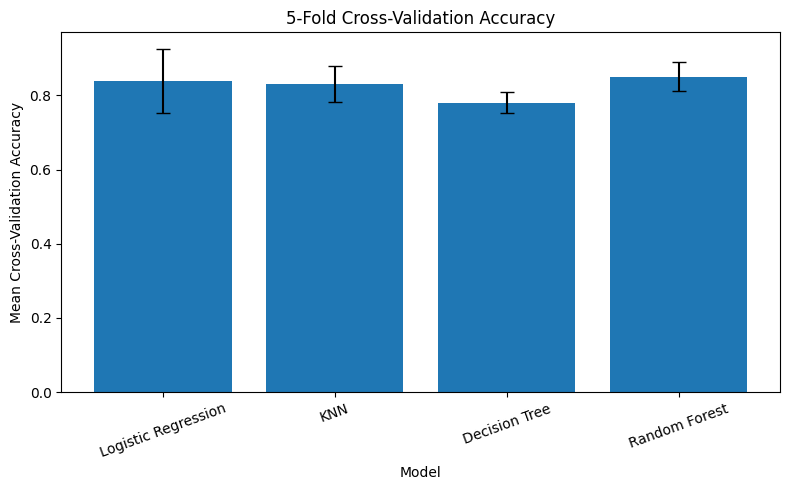

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    cv_results_df["Model"],
    cv_results_df["Accuracy Mean"],
    yerr=cv_results_df["Accuracy Std"],
    capsize=5
)

plt.ylabel("Mean Cross-Validation Accuracy")
plt.xlabel("Model")
plt.title("5-Fold Cross-Validation Accuracy")

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

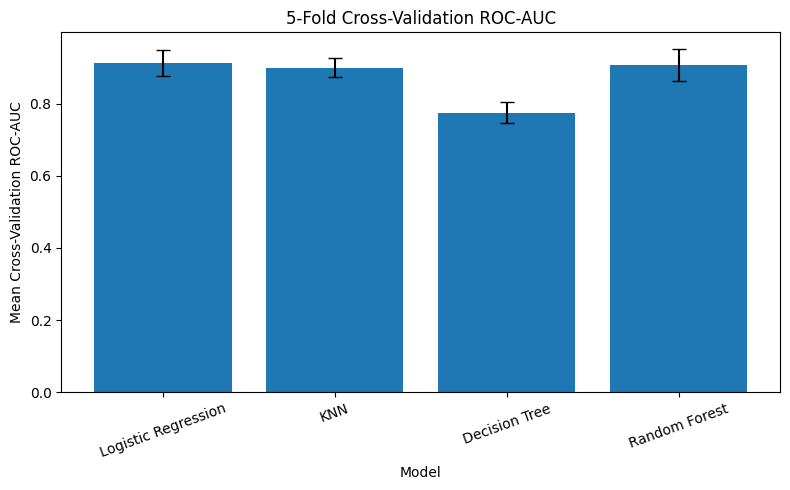

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    cv_results_df["Model"],
    cv_results_df["ROC-AUC Mean"],
    yerr=cv_results_df["ROC-AUC Std"],
    capsize=5
)

plt.ylabel("Mean Cross-Validation ROC-AUC")
plt.xlabel("Model")
plt.title("5-Fold Cross-Validation ROC-AUC")

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

In [ ]:
cv_results_df.to_csv(
    RESULT_PATH + "/cross_validation_results.csv",
    index=False
)

# **Findings**

## Cross-Validation Findings

Purpose

Five-fold stratified cross-validation was used to evaluate the stability
of the baseline machine learning models.

Observations

- Cross-validation provides a more reliable estimate of model performance
  than relying on a single train/test split.
- The mean score represents the average performance across five folds.
- The standard deviation indicates how much performance varied between
  folds.
- Model ranking may differ from the single test-set evaluation.
- The final model should not be selected based on accuracy alone.

Important Experimental Design

The original test set was separated before cross-validation and was not
used during the cross-validation process. It will be reserved for final
evaluation after model selection.